In [1]:
import os
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
project_root = Path(os.environ["PROJECT_ROOT"])

hcp_fd_dir = project_root / "results/hcp_1200_rfmri_fd"
hcp_fd = pd.read_parquet(hcp_fd_dir / "hcp_1200_rfmri_fd.parquet")

# Only include 3T data
hcp_fd = hcp_fd.query("mag == '3T'")

print(hcp_fd.shape)
print(hcp_fd.head(5))

(4233, 6)
      sub    mod   task mag dir        fd
0  100206  rfMRI  REST1  3T  LR  0.099991
1  100206  rfMRI  REST1  3T  RL  0.105217
2  100206  rfMRI  REST2  3T  LR  0.123617
3  100206  rfMRI  REST2  3T  RL  0.106713
4  100307  rfMRI  REST1  3T  LR  0.120536


In [4]:
hcp_fd_grouped = hcp_fd.groupby("sub").agg({"task": "count", "fd": "mean"})

hcp_fd_grouped = hcp_fd_grouped.reset_index()
hcp_fd_grouped.columns = ["sub", "run_count", "mean_fd"]

print(hcp_fd_grouped.shape)
print(hcp_fd_grouped.head(5))

(1096, 3)
      sub  run_count   mean_fd
0  100206          4  0.108884
1  100307          4  0.125204
2  100408          4  0.183484
3  100610          4  0.180003
4  101006          4  0.155110


In [5]:
print(hcp_fd_grouped["run_count"].value_counts())

run_count
4    1018
2      61
3      11
1       6
Name: count, dtype: int64


In [6]:
hcp_fd_grouped_full = hcp_fd_grouped.query("run_count == 4")
print(hcp_fd_grouped_full.shape)

(1018, 3)


In [7]:
def boxplot_outlier_threshold(values: np.ndarray) -> tuple[float, float]:
    q1, q3 = np.quantile(values, [0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

In [8]:
_, outlier_thr = boxplot_outlier_threshold(hcp_fd_grouped_full["mean_fd"])
outlier_thr = round(outlier_thr, 2)

print(f"FD outlier threshold: {outlier_thr}")

FD outlier threshold: 0.28


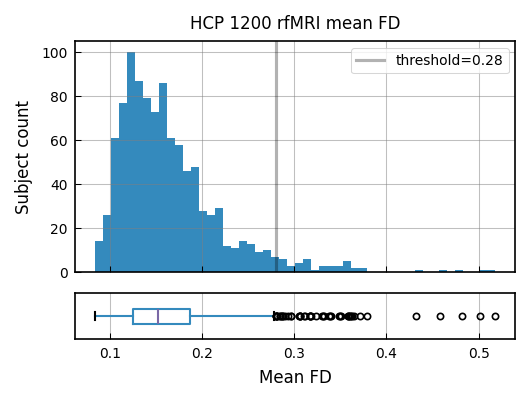

In [9]:
f, axs = plt.subplots(
    2,
    1,
    gridspec_kw={"height_ratios": [1.0, 0.2]},
    figsize=(PLOTW, 0.75 * PLOTW),
    layout="constrained",
    sharex=True,
)

plt.sca(axs[0])
plt.hist(hcp_fd_grouped_full["mean_fd"], bins=50)
plt.axvline(outlier_thr, color="k", alpha=0.3, label=f"threshold={outlier_thr}")
plt.ylabel("Subject count")
plt.title("HCP 1200 rfMRI mean FD")
plt.legend()

plt.sca(axs[1])
hcp_fd_grouped_full.boxplot(column="mean_fd", vert=False, widths=1 / 3)
plt.yticks([])
plt.xlabel("Mean FD")

plt.savefig(hcp_fd_dir / f"hcp_1200_rfmri_fd.{FORMAT}")